# **Linear Regression with sklearn**

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [28]:
data=yf.download(["BSE.NS","BEL.NS","HAL.NS"],start="2026-01-05",end="2026-01-09",interval="5m",)
arr=np.array(data["Close"])
df=pd.DataFrame(data["Close"])
df

/tmp/ipython-input-2149182726.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(["BSE.NS","BEL.NS","HAL.NS"],start="2026-01-05",end="2026-01-09",interval="5m",)
[*********************100%***********************]  3 of 3 completed


Ticker,BEL.NS,BSE.NS,HAL.NS
Datetime,,,
2026-01-05 03:45:00+00:00,408.450012,2650.500000,4482.399902
2026-01-05 03:50:00+00:00,408.700012,2649.000000,4473.600098
2026-01-05 03:55:00+00:00,409.549988,2638.000000,4472.200195
2026-01-05 04:00:00+00:00,410.149994,2628.399902,4488.799805
2026-01-05 04:05:00+00:00,411.200012,2622.199951,4487.000000
...,...,...,...
2026-01-08 09:35:00+00:00,415.649994,2696.800049,4476.899902
2026-01-08 09:40:00+00:00,415.700012,2696.000000,4484.399902
2026-01-08 09:45:00+00:00,415.000000,2687.899902,4478.200195


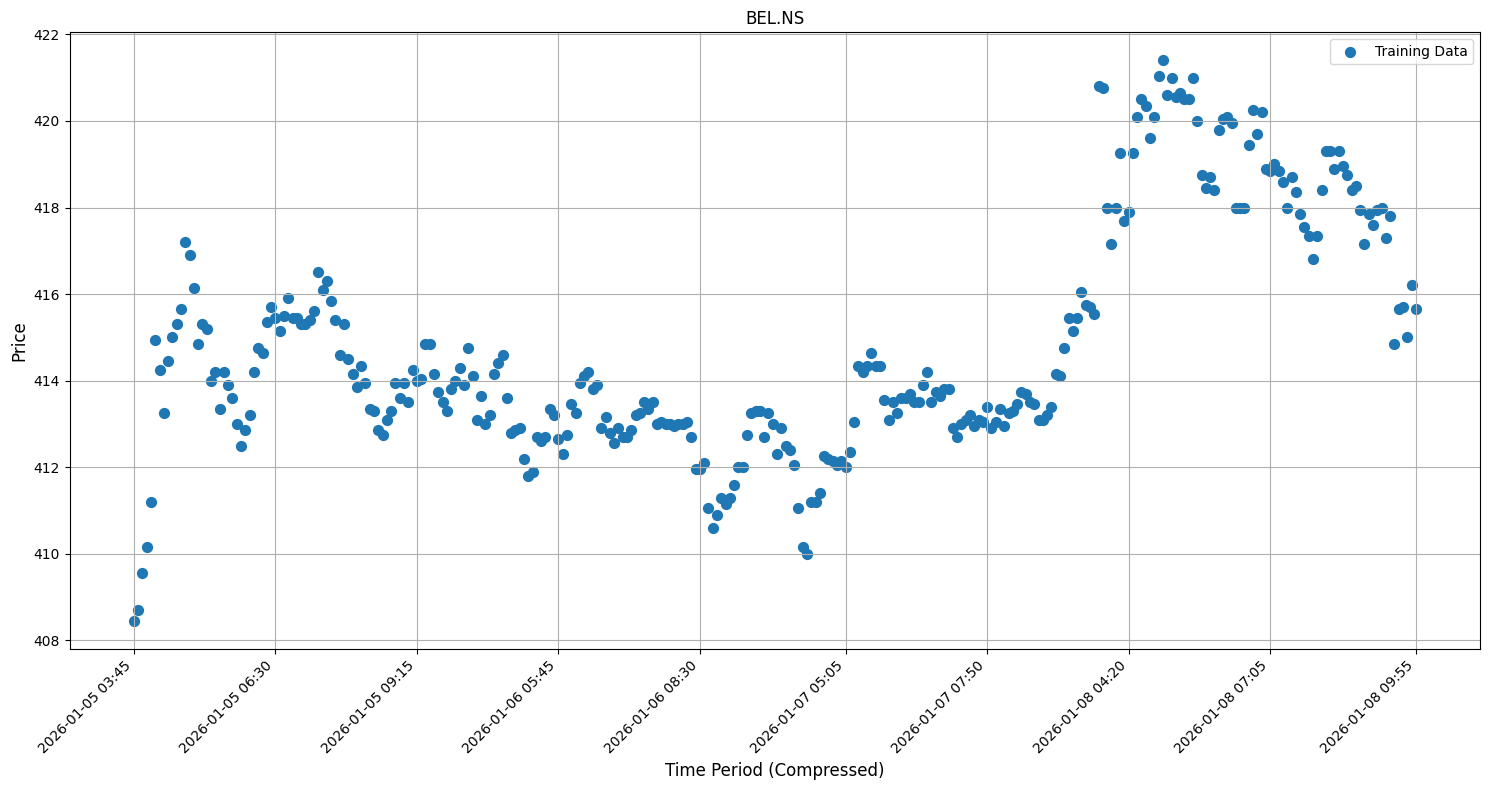

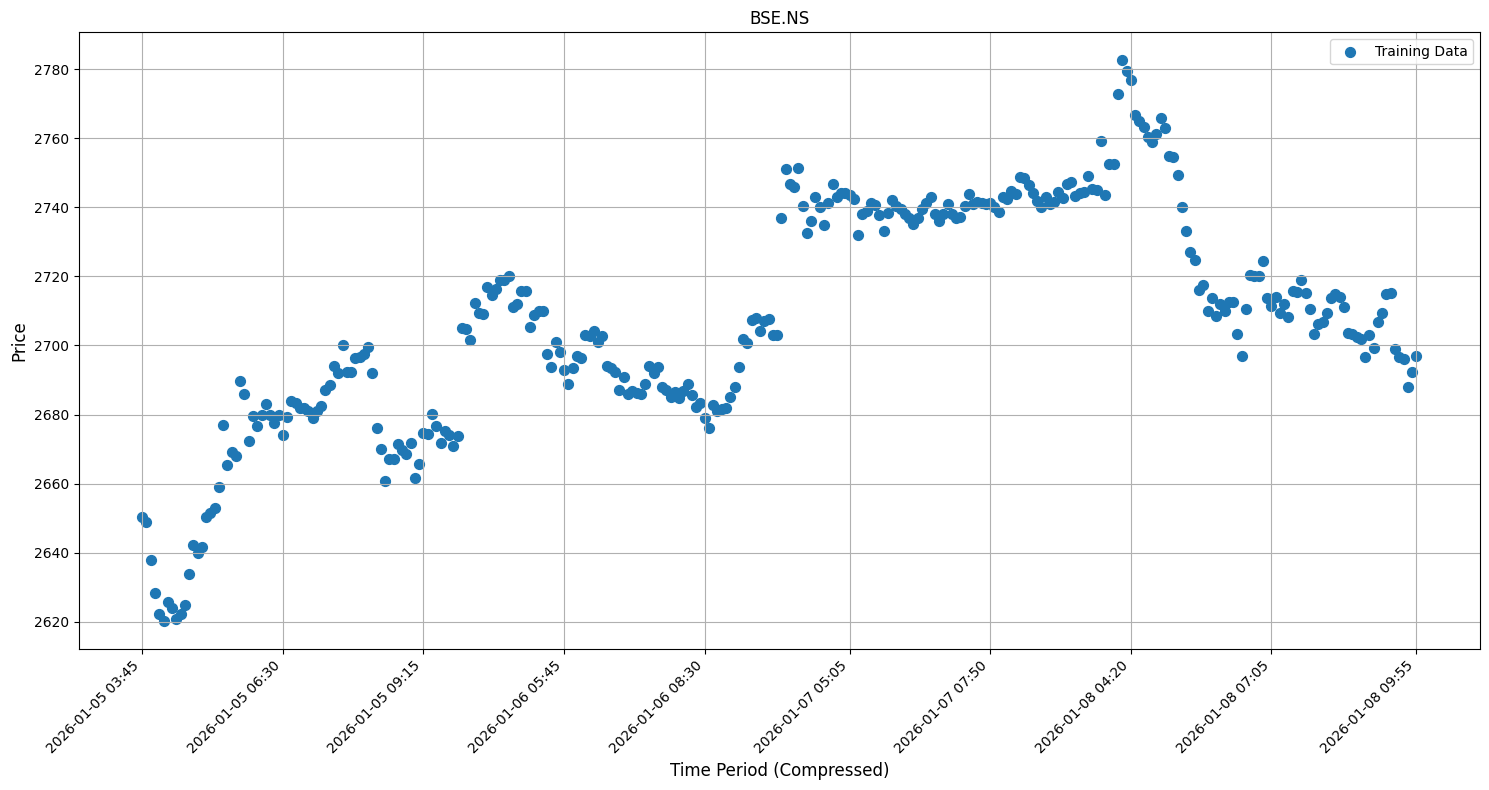

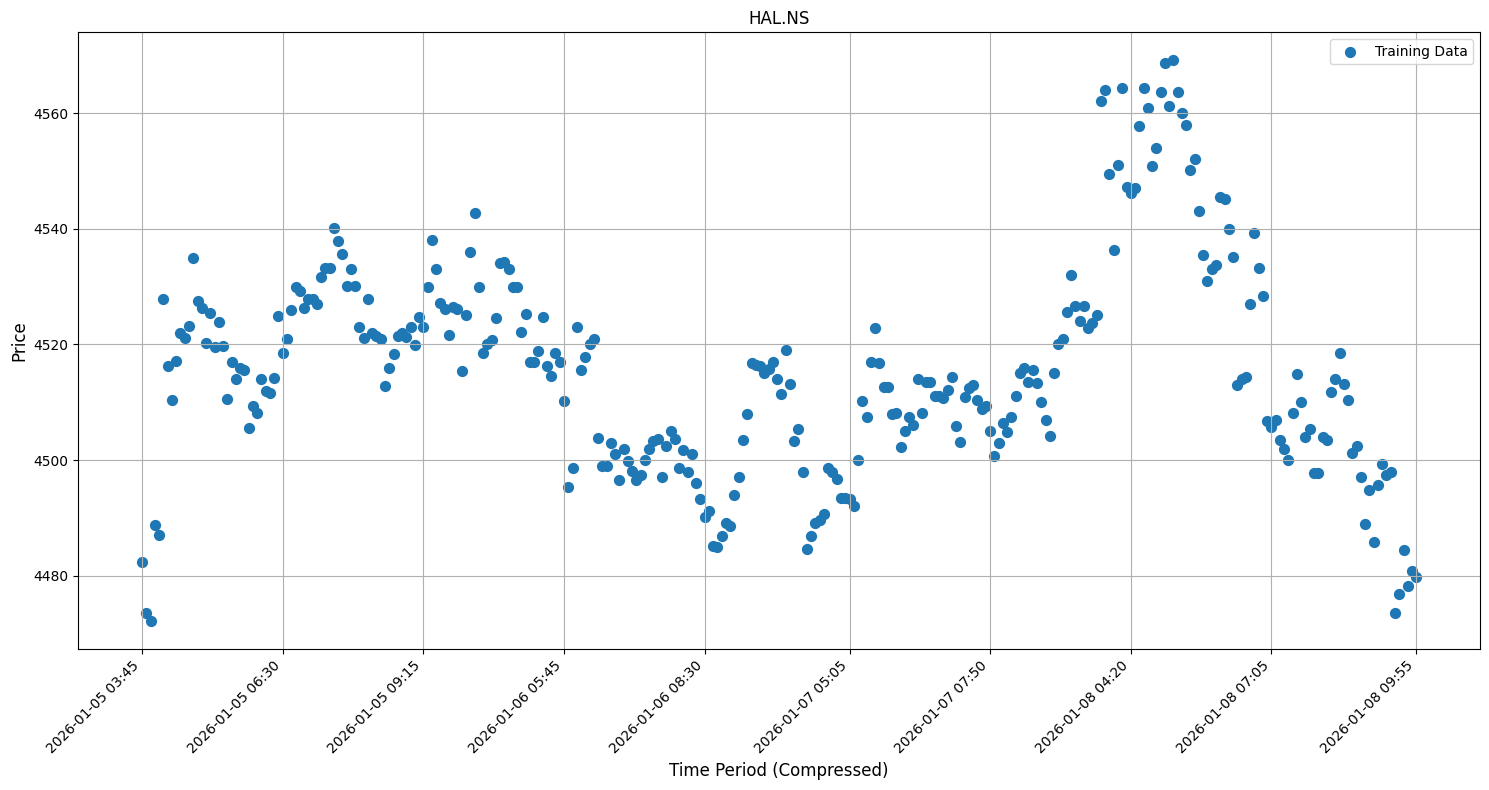

In [29]:
for ticker in df.columns:
  plt.figure(figsize=(15,8))
  # Use numerical index for x-axis to remove gaps
  x_values = np.arange(len(df[ticker]))
  plt.scatter(x=x_values, y=df[ticker], s=50, label="Training Data")
  plt.title(ticker)
  plt.xlabel("Time Period (Compressed)", fontsize=12)
  plt.ylabel("Price", fontsize=12)

  # To add meaningful time labels on the x-axis:
  # Select a reasonable number of ticks, e.g., 8-10 ticks
  num_ticks = min(len(df[ticker]), 10) # Ensure num_ticks doesn't exceed data length
  tick_positions = np.linspace(0, len(df[ticker]) - 1, num_ticks, dtype=int)
  tick_labels = df.index[tick_positions].strftime('%Y-%m-%d %H:%M')
  plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

  plt.legend()
  plt.grid(True)
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

In [32]:
lm=LinearRegression(fit_intercept=True)

for ticker in df.columns:
  lm.fit(x_values.reshape(-1, 1), df[ticker])
  # Now coef_ and intercept_ are available for the current ticker's fit
  slope = lm.coef_[0]
  intercept = lm.intercept_
  df[f"Pred {ticker}"]=lm.predict(x_values.reshape(-1, 1))

  # If you want to use x_lin and y_lin for plotting the regression line for each ticker,
  # this part should be inside the loop as well, using the current slope and intercept.
  # For now, I'm keeping them commented out or removing them as their purpose outside
  # the loop with these uninitialized variables was incorrect.
  # x_lin=np.array([0,100])
  # y_lin=intercept+slope*x_lin